In [1]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4


In [2]:
!pip install -q transformers datasets evaluate accelerate scikit-learn pandas numpy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [3]:
import transformers
import datasets
import evaluate
import torch
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("torch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

transformers: 5.0.0
datasets: 4.0.0
evaluate: 0.4.6
torch: 2.10.0+cu128
GPU: Tesla T4


# Deep Learning Question Answering for Document Intelligence

This notebook builds an extractive QA pipeline using transformer models, evaluates a pretrained baseline, fine-tunes DistilBERT on SQuAD, and compares Exact Match (EM) and F1.

In [4]:
from pathlib import Path
import json
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator,
)

PROJECT_NAME = "qa_transformer_project"

print("Project:", PROJECT_NAME)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Project: qa_transformer_project
Torch: 2.10.0+cu128
CUDA available: True
Device: Tesla T4


In [5]:
print("Loading SQuAD...")
dataset = load_dataset("squad")

train_ds = dataset["train"]
val_ds = dataset["validation"]

print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Columns:", train_ds.column_names)

sample = train_ds[0]
print("\nSample example:")
for k, v in sample.items():
    print(f"\n--- {k} ---")
    print(v)

Loading SQuAD...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Train size: 87599
Validation size: 10570
Columns: ['id', 'title', 'context', 'question', 'answers']

Sample example:

--- id ---
5733be284776f41900661182

--- title ---
University_of_Notre_Dame

--- context ---
Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.

--- question ---
To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?

--

In [6]:
summary = {
    "train_size": len(train_ds),
    "validation_size": len(val_ds),
    "columns": train_ds.column_names,
}

summary

{'train_size': 87599,
 'validation_size': 10570,
 'columns': ['id', 'title', 'context', 'question', 'answers']}

## 2. Pretrained Baseline QA Model

In [7]:
def answer_question(tokenizer, model, question, context, max_length=512, max_answer_length=30):
    """
    Run extractive QA for one question-context pair using a constrained best-span search.
    """
    inputs = tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )

    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    start_logits = outputs.start_logits[0]
    end_logits = outputs.end_logits[0]
    input_ids = inputs["input_ids"][0]

    best_score = float("-inf")
    best_start = 0
    best_end = 0

    for start_idx in range(len(start_logits)):
        max_end_idx = min(start_idx + max_answer_length, len(end_logits))
        for end_idx in range(start_idx, max_end_idx):
            score = start_logits[start_idx].item() + end_logits[end_idx].item()
            if score > best_score:
                best_score = score
                best_start = start_idx
                best_end = end_idx

    answer_tokens = input_ids[best_start : best_end + 1]
    answer = tokenizer.decode(answer_tokens, skip_special_tokens=True).strip()

    start_prob = torch.softmax(start_logits, dim=0)[best_start].item()
    end_prob = torch.softmax(end_logits, dim=0)[best_end].item()
    confidence = (start_prob + end_prob) / 2.0

    return {
        "answer": answer,
        "score": confidence,
        "start_idx": best_start,
        "end_idx": best_end,
    }

In [8]:
BASELINE_MODEL_NAME = "bert-large-uncased-whole-word-masking-finetuned-squad"

print("Loading baseline model:", BASELINE_MODEL_NAME)

baseline_tokenizer = AutoTokenizer.from_pretrained(BASELINE_MODEL_NAME)
baseline_model = AutoModelForQuestionAnswering.from_pretrained(BASELINE_MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model.to(device)
baseline_model.eval()

print("Baseline model loaded.")
print("Device:", device)

Loading baseline model: bert-large-uncased-whole-word-masking-finetuned-squad


config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Baseline model loaded.
Device: cuda


In [9]:
baseline_results = []

for i in range(5):
    example = val_ds[i]

    question = example["question"]
    context = example["context"]
    gold_answer = example["answers"]["text"][0]

    pred = answer_question(
        tokenizer=baseline_tokenizer,
        model=baseline_model,
        question=question,
        context=context,
    )

    baseline_results.append({
        "question": question,
        "gold_answer": gold_answer,
        "predicted_answer": pred["answer"],
        "confidence": pred["score"],
    })

    print("\n----------------------------------------")
    print("Question:", question)
    print("Gold:", gold_answer)
    print("Predicted:", pred["answer"])
    print("Confidence:", round(pred["score"], 4))


----------------------------------------
Question: Which NFL team represented the AFC at Super Bowl 50?
Gold: Denver Broncos
Predicted: denver broncos
Confidence: 0.9947

----------------------------------------
Question: Which NFL team represented the NFC at Super Bowl 50?
Gold: Carolina Panthers
Predicted: carolina panthers
Confidence: 0.9987

----------------------------------------
Question: Where did Super Bowl 50 take place?
Gold: Santa Clara, California
Predicted: levi ' s stadium in the san francisco bay area at santa clara, california
Confidence: 0.5693

----------------------------------------
Question: Which NFL team won Super Bowl 50?
Gold: Denver Broncos
Predicted: denver broncos
Confidence: 0.981

----------------------------------------
Question: What color was used to emphasize the 50th anniversary of the Super Bowl?
Gold: gold
Predicted: gold
Confidence: 0.9026


## 3. Baseline Evaluation: Exact Match (EM) and F1

In [10]:
def normalize_answer(s):
    """
    Lower text and remove punctuation, articles, and extra whitespace.
    """
    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def white_space_fix(text):
        return " ".join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))


def compute_exact(a_gold, a_pred):
    return int(normalize_answer(a_gold) == normalize_answer(a_pred))


def compute_f1(a_gold, a_pred):
    gold_toks = normalize_answer(a_gold).split()
    pred_toks = normalize_answer(a_pred).split()

    common = Counter(gold_toks) & Counter(pred_toks)
    num_same = sum(common.values())

    if len(gold_toks) == 0 or len(pred_toks) == 0:
        return float(gold_toks == pred_toks)

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_toks)
    recall = num_same / len(gold_toks)
    return 2 * precision * recall / (precision + recall)

In [11]:
n_eval = 100

baseline_eval_results = []
baseline_em_scores = []
baseline_f1_scores = []

for i in range(n_eval):
    example = val_ds[i]

    question = example["question"]
    context = example["context"]
    gold_answers = example["answers"]["text"]

    pred = answer_question(
        tokenizer=baseline_tokenizer,
        model=baseline_model,
        question=question,
        context=context,
    )

    pred_answer = pred["answer"]

    em = max(compute_exact(gold, pred_answer) for gold in gold_answers)
    f1 = max(compute_f1(gold, pred_answer) for gold in gold_answers)

    baseline_em_scores.append(em)
    baseline_f1_scores.append(f1)

    baseline_eval_results.append({
        "id": example["id"],
        "question": question,
        "predicted_answer": pred_answer,
        "gold_answers": gold_answers,
        "confidence": pred["score"],
        "exact_match": em,
        "f1": f1,
    })

baseline_em = 100 * np.mean(baseline_em_scores)
baseline_f1 = 100 * np.mean(baseline_f1_scores)

print("Baseline QA Evaluation")
print("======================")
print(f"Examples evaluated : {n_eval}")
print(f"Exact Match (EM)   : {baseline_em:.2f}")
print(f"F1 Score           : {baseline_f1:.2f}")

Baseline QA Evaluation
Examples evaluated : 100
Exact Match (EM)   : 84.00
F1 Score           : 90.64


In [12]:
baseline_eval_df = pd.DataFrame(baseline_eval_results)
baseline_eval_df.head(10)

,id,question,predicted_answer,gold_answers,confidence,exact_match,f1
0,56be4db0acb8001400a502ec,Which NFL team represented the AFC at Super Bo...,denver broncos,"[Denver Broncos, Denver Broncos, Denver Broncos]",0.994727,1,1.000000
1,56be4db0acb8001400a502ed,Which NFL team represented the NFC at Super Bo...,carolina panthers,"[Carolina Panthers, Carolina Panthers, Carolin...",0.998748,1,1.000000
2,56be4db0acb8001400a502ee,Where did Super Bowl 50 take place?,levi ' s stadium in the san francisco bay area...,"[Santa Clara, California, Levi's Stadium, Levi...",0.569311,0,0.869565
3,56be4db0acb8001400a502ef,Which NFL team won Super Bowl 50?,denver broncos,"[Denver Broncos, Denver Broncos, Denver Broncos]",0.980980,1,1.000000
4,56be4db0acb8001400a502f0,What color was used to emphasize the 50th anni...,gold,"[gold, gold, gold]",0.902562,1,1.000000
5,56be8e613aeaaa14008c90d1,What was the theme of Super Bowl 50?,golden anniversary,"[""golden anniversary"", gold-themed, ""golden an...",0.529665,1,1.000000
6,56be8e613aeaaa14008c90d2,What day was the game played on?,"february 7, 2016","[February 7, 2016, February 7, February 7, 2016]",0.931940,1,1.000000
7,56be8e613aeaaa14008c90d3,What is the AFC short for?,american football conference,"[American Football Conference, American Footba...",0.993691,1,1.000000
8,56bea9923aeaaa14008c91b9,What was the theme of Super Bowl 50?,golden anniversary,"[""golden anniversary"", gold-themed, gold]",0.529665,1,1.000000
9,56bea9923aeaaa14008c91ba,What does AFC stand for?,american football conference,"[American Football Conference, American Footba...",0.994863,1,1.000000


## 4. Fine-Tune DistilBERT for Extractive QA

In [13]:
FINETUNE_MODEL_NAME = "bert-base-uncased"

print("Loading fine-tuning model:", FINETUNE_MODEL_NAME)

finetune_tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)
finetune_model = AutoModelForQuestionAnswering.from_pretrained(FINETUNE_MODEL_NAME)

finetune_model.to(device)

print("Fine-tuning model loaded.")
print("Device:", device)

Loading fine-tuning model: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
qa_outputs.weight                          | MISSING    | 
qa_outputs.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Fine-tuning model loaded.
Device: cuda


In [14]:
MAX_LENGTH = 384
DOC_STRIDE = 128

def prepare_train_features(examples, tokenizer):
    questions = [q.strip() for q in examples["question"]]

    tokenized_examples = tokenizer(
        questions,
        examples["context"],
        max_length=MAX_LENGTH,
        truncation="only_second",
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized_examples.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized_examples.pop("offset_mapping")

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized_examples["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)

        sequence_ids = tokenized_examples.sequence_ids(i)
        sample_index = sample_mapping[i]
        answers = examples["answers"][sample_index]

        if len(answers["answer_start"]) == 0:
            start_positions.append(cls_index)
            end_positions.append(cls_index)
            continue

        start_char = answers["answer_start"][0]
        end_char = start_char + len(answers["text"][0])

        token_start_index = 0
        while sequence_ids[token_start_index] != 1:
            token_start_index += 1

        token_end_index = len(input_ids) - 1
        while sequence_ids[token_end_index] != 1:
            token_end_index -= 1

        if not (
            offsets[token_start_index][0] <= start_char
            and offsets[token_end_index][1] >= end_char
        ):
            start_positions.append(cls_index)
            end_positions.append(cls_index)
        else:
            while (
                token_start_index < len(offsets)
                and offsets[token_start_index][0] <= start_char
            ):
                token_start_index += 1
            start_positions.append(token_start_index - 1)

            while offsets[token_end_index][1] >= end_char:
                token_end_index -= 1
            end_positions.append(token_end_index + 1)

    tokenized_examples["start_positions"] = start_positions
    tokenized_examples["end_positions"] = end_positions

    return tokenized_examples

In [15]:
train_subset = train_ds.select(range(20000))
val_subset = val_ds.select(range(1000))

print("Train subset size:", len(train_subset))
print("Validation subset size:", len(val_subset))

Train subset size: 20000
Validation subset size: 1000


In [16]:
tokenized_train = train_subset.map(
    lambda x: prepare_train_features(x, finetune_tokenizer),
    batched=True,
    remove_columns=train_subset.column_names,
)

tokenized_val = val_subset.map(
    lambda x: prepare_train_features(x, finetune_tokenizer),
    batched=True,
    remove_columns=val_subset.column_names,
)

print("Tokenized train size:", len(tokenized_train))
print("Tokenized validation size:", len(tokenized_val))

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenized train size: 20164
Tokenized validation size: 1020


In [17]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./outputs/models/bert_base_qa_final",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [18]:
trainer = Trainer(
    model=finetune_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=default_data_collator,
)

In [19]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss
1,1.214110,1.203860
2,0.885271,1.193672


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2522, training_loss=1.3073166295897856, metrics={'train_runtime': 965.272, 'train_samples_per_second': 41.779, 'train_steps_per_second': 2.613, 'total_flos': 7903181704237056.0, 'train_loss': 1.3073166295897856, 'epoch': 2.0})

## 5. Evaluate the Fine-Tuned DistilBERT Model

In [20]:
n_eval = 100

finetuned_eval_results = []
finetuned_em_scores = []
finetuned_f1_scores = []

finetune_model.eval()

for i in range(n_eval):
    example = val_ds[i]

    question = example["question"]
    context = example["context"]
    gold_answers = example["answers"]["text"]

    pred = answer_question(
        tokenizer=finetune_tokenizer,
        model=finetune_model,
        question=question,
        context=context,
    )

    pred_answer = pred["answer"]

    em = max(compute_exact(gold, pred_answer) for gold in gold_answers)
    f1 = max(compute_f1(gold, pred_answer) for gold in gold_answers)

    finetuned_em_scores.append(em)
    finetuned_f1_scores.append(f1)

    finetuned_eval_results.append({
        "id": example["id"],
        "question": question,
        "predicted_answer": pred_answer,
        "gold_answers": gold_answers,
        "confidence": pred["score"],
        "exact_match": em,
        "f1": f1,
    })

finetuned_em = 100 * np.mean(finetuned_em_scores)
finetuned_f1 = 100 * np.mean(finetuned_f1_scores)

print("Fine-Tuned DistilBERT Evaluation")
print("================================")
print(f"Examples evaluated : {n_eval}")
print(f"Exact Match (EM)   : {finetuned_em:.2f}")
print(f"F1 Score           : {finetuned_f1:.2f}")

Fine-Tuned DistilBERT Evaluation
Examples evaluated : 100
Exact Match (EM)   : 71.00
F1 Score           : 80.32


In [21]:
finetuned_eval_df = pd.DataFrame(finetuned_eval_results)
finetuned_eval_df.head(10)

,id,question,predicted_answer,gold_answers,confidence,exact_match,f1
0,56be4db0acb8001400a502ec,Which NFL team represented the AFC at Super Bo...,denver broncos,"[Denver Broncos, Denver Broncos, Denver Broncos]",0.946691,1,1.0
1,56be4db0acb8001400a502ed,Which NFL team represented the NFC at Super Bo...,carolina panthers,"[Carolina Panthers, Carolina Panthers, Carolin...",0.758770,1,1.0
2,56be4db0acb8001400a502ee,Where did Super Bowl 50 take place?,"santa clara, california","[Santa Clara, California, Levi's Stadium, Levi...",0.475634,1,1.0
3,56be4db0acb8001400a502ef,Which NFL team won Super Bowl 50?,denver broncos,"[Denver Broncos, Denver Broncos, Denver Broncos]",0.751565,1,1.0
4,56be4db0acb8001400a502f0,What color was used to emphasize the 50th anni...,gold,"[gold, gold, gold]",0.970614,1,1.0
5,56be8e613aeaaa14008c90d1,What was the theme of Super Bowl 50?,champion of the national football league ( nfl ),"[""golden anniversary"", gold-themed, ""golden an...",0.180156,0,0.0
6,56be8e613aeaaa14008c90d2,What day was the game played on?,"february 7, 2016","[February 7, 2016, February 7, February 7, 2016]",0.966592,1,1.0
7,56be8e613aeaaa14008c90d3,What is the AFC short for?,american football conference ( afc ) champion ...,"[American Football Conference, American Footba...",0.513516,0,0.6
8,56bea9923aeaaa14008c91b9,What was the theme of Super Bowl 50?,champion of the national football league ( nfl ),"[""golden anniversary"", gold-themed, gold]",0.180156,0,0.0
9,56bea9923aeaaa14008c91ba,What does AFC stand for?,american football conference,"[American Football Conference, American Footba...",0.810754,1,1.0


In [22]:
comparison_df = pd.DataFrame([
    {
        "model": "Pretrained BERT QA",
        "exact_match": baseline_em,
        "f1": baseline_f1
    },
    {
        "model": "Fine-Tuned DistilBERT QA",
        "exact_match": finetuned_em,
        "f1": finetuned_f1
    }
])

comparison_df

,model,exact_match,f1
0,Pretrained BERT QA,84.0,90.636232
1,Fine-Tuned DistilBERT QA,71.0,80.316667


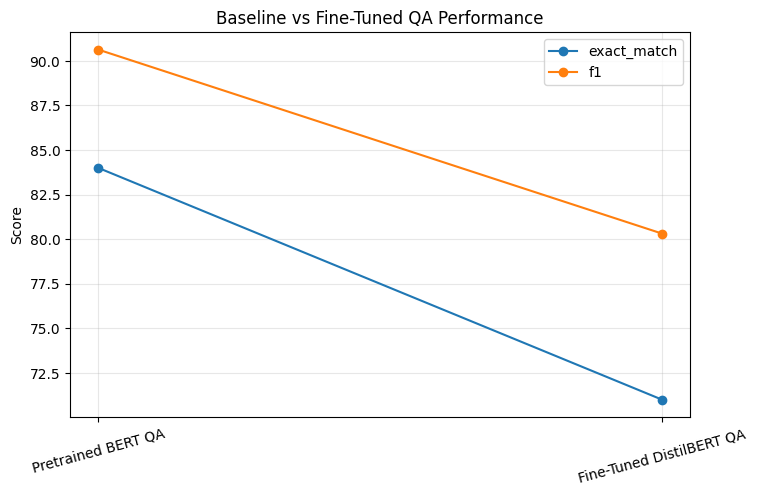

In [23]:
comparison_long = comparison_df.melt(
    id_vars="model",
    value_vars=["exact_match", "f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(8, 5))
for metric in ["exact_match", "f1"]:
    subset = comparison_long[comparison_long["metric"] == metric]
    plt.plot(subset["model"], subset["score"], marker="o", label=metric)

plt.ylabel("Score")
plt.title("Baseline vs Fine-Tuned QA Performance")
plt.legend()
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.show()

## 6. Error Analysis: Why Did Fine-Tuning Degrade Performance?

In [24]:
error_cases = finetuned_eval_df[
    (finetuned_eval_df["exact_match"] == 0) &
    (finetuned_eval_df["f1"] < 0.5)
]

error_cases[["question", "predicted_answer", "gold_answers", "confidence"]].head(10)

,question,predicted_answer,gold_answers,confidence
5,What was the theme of Super Bowl 50?,champion of the national football league ( nfl ),"[""golden anniversary"", gold-themed, ""golden an...",0.180156
8,What was the theme of Super Bowl 50?,champion of the national football league ( nfl ),"[""golden anniversary"", gold-themed, gold]",0.180156
12,What venue did Super Bowl 50 take place in?,levi ' s stadium,"[Levi's Stadium, Levi's Stadium, Levi's Stadiu...",0.915604
18,What stadium did Super Bowl 50 take place in?,levi ' s stadium,"[Levi's Stadium, Levi's Stadium, Levi's Stadium]",0.974804
19,What was the final score of Super Bowl 50?,24 – 10,"[24–10, 24–10, 24–10]",0.216688
27,Where was Super Bowl 50 held?,levi ' s stadium,"[Santa Clara, California., Levi's Stadium, Lev...",0.440853
38,How many teams have been in the Super Bowl eig...,pittsburgh steelers,"[four, four, four]",0.495634
40,What was the win/loss ratio in 2015 for the Ca...,15 – 1,"[15–1, 15–1, 15–1]",0.557708
42,What were the win/loss game stats for the Denv...,12 – 4,"[12–4, 12–4, 12–4]",0.714561
43,How many teams have played in the Super Bowl e...,pittsburgh steelers,"[4, four, four]",0.587170
